# Logistic Regression in 2D — Watching It Draw the Line

When we first learned logistic regression, we used **one feature** (study hours) and the model gave an S-curve — a threshold on a single number. But we never *saw* the thing logistic regression is famous for: **drawing a straight line that separates two groups of points.**

That's what this notebook is about. With **two features**, the decision boundary becomes an actual **line on a graph**, dividing the plane into "predict yes" and "predict no." You'll see it, and understand exactly where it comes from.

**The project:** university admissions. Given a student's scores on **two exams**, predict whether they were **admitted**. Two features → we can plot everything and watch the boundary appear.

**The plan:**
1. See the two-feature data as points on a graph.
2. Train logistic regression on both features.
3. Draw the decision boundary — the separating line.
4. Understand *why* it's a line, and shade the two regions.
5. Predict a new student and see which side they fall on.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## 1. The data: two exam scores

Each student has two exam scores and an outcome: **admitted (1)** or **not admitted (0)**. Two features means we can put exam 1 on the x-axis, exam 2 on the y-axis, and show every student as a point.

In [12]:
df = pd.read_csv(r"D:\AI\Artificial-Intelligence-Machine-Learning-and-Deep-Learning-Corvit-Peshawar-2026\Artificial-Inteligence-Machine-Learning-and-Deep-Learning-NAVTTC-Course-2026\week-07-completing-classical-ML\datasets\admissions.csv")
print("shape:", df.shape)
print("admitted rate:", round(df["admitted"].mean(), 2))
df.head()

shape: (100, 3)
admitted rate: 0.61


,exam1,exam2,admitted
0,76.13,73.79,1
1,49.33,60.89,0
2,39.82,68.46,0
3,20.00,74.84,0
4,59.35,87.94,1


Now plot the students, colouring by outcome — **red = admitted**, **blue = not admitted.**

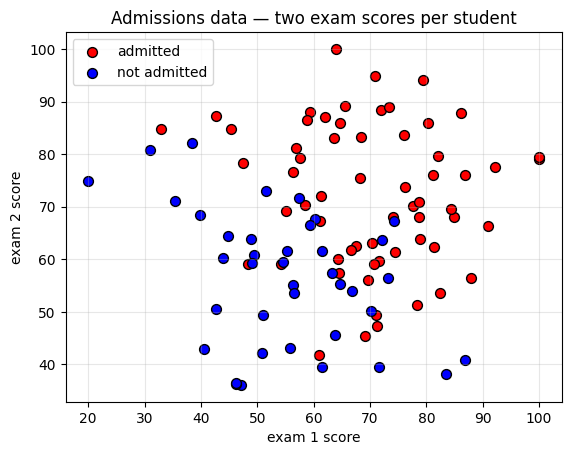

In [13]:
def plot_students(df):
    admitted = df[df["admitted"] == 1]
    rejected = df[df["admitted"] == 0]
    plt.scatter(admitted["exam1"], admitted["exam2"], c="red", label="admitted", edgecolor="k", s=50)
    plt.scatter(rejected["exam1"], rejected["exam2"], c="blue", label="not admitted", edgecolor="k", s=50)
    plt.xlabel("exam 1 score"); 
    plt.ylabel("exam 2 score")
    plt.legend(); 
    plt.grid(True, alpha=0.3)

plot_students(df)
plt.title("Admissions data — two exam scores per student")
plt.show()

Look at the structure: the **red (admitted)** students cluster toward the **top-right** (high on both exams), and the **blue (not admitted)** toward the **bottom-left**. There's a clear diagonal divide.

You can almost *see* where a line should go to separate them. Logistic regression's job is to find that line — precisely, from the data. Let's train it.

---
## 2. Train logistic regression on both features

Same model as before — the only difference is it now takes **two** inputs (`exam1` and `exam2`) instead of one. Under the hood it computes:

$$ z = w_1 \cdot \text{exam1} + w_2 \cdot \text{exam2} + b $$

then passes `z` through the sigmoid to get a probability. Two weights now (one per feature), plus the bias.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[["exam1", "exam2"]].values      # TWO features now
y = df["admitted"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

model = LogisticRegression()
model.fit(X_train, y_train)

print("accuracy on test set:", round(model.score(X_test, y_test), 3))
print("\nlearned parameters:")
print("all coeficient : ", model.coef_)
print(f"  w1 (exam1 weight) = {model.coef_[0][0]:.3f}")
print(f"  w2 (exam2 weight) = {model.coef_[0][1]:.3f}")
print(f"  b  (bias)         = {model.intercept_[0]:.3f}")

accuracy on test set: 0.88

learned parameters:
all coeficient :  [[0.10384474 0.11195888]]
  w1 (exam1 weight) = 0.104
  w2 (exam2 weight) = 0.112
  b  (bias)         = -13.133


Both weights are positive — higher scores on *either* exam push toward admission, which makes sense. Now the interesting part: turning those three numbers into a line we can draw.

---
## 3. Drawing the decision boundary

The model predicts **admitted** when the probability ≥ 0.5. The sigmoid equals 0.5 exactly when its input `z = 0`. So the **decision boundary** is the set of points where:

$$ w_1 \cdot \text{exam1} + w_2 \cdot \text{exam2} + b = 0 $$

That's the equation of a **straight line!** We can rearrange it to solve for exam2:

$$ \text{exam2} = -\frac{w_1 \cdot \text{exam1} + b}{w_2} $$

Let's compute that line and draw it over the data.

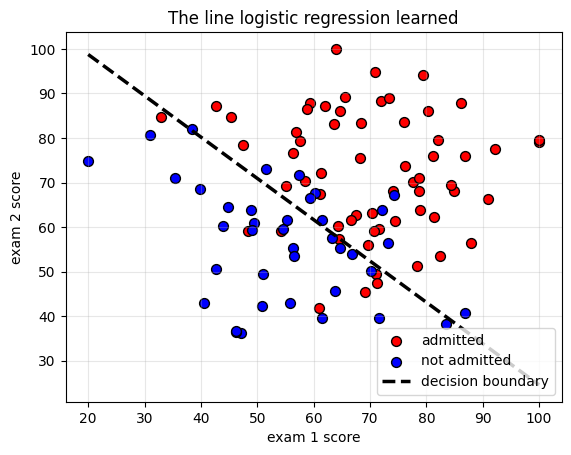

In [17]:
w1, w2 = model.coef_[0]  
b = model.intercept_[0]

# pick two exam1 values spanning the range, compute the matching exam2 on the boundary
exam1_line = np.array([df["exam1"].min(), df["exam1"].max()])
exam2_line = -(w1 * exam1_line + b) / w2


plot_students(df)
plt.plot(exam1_line, exam2_line, "k--", linewidth=2.5, label="decision boundary")
plt.legend()
plt.title("The line logistic regression learned")
plt.show()

**There it is** — the straight line logistic regression drew to separate admitted from not-admitted. This is the picture students always hear about but rarely see. Everything on one side, the model predicts "admitted"; everything on the other, "not admitted."

The line isn't perfect — a few points sit on the wrong side (those are the model's mistakes, the ones that cost us the missing accuracy). But it captures the diagonal divide beautifully, purely from the data.

---
## 4. Shading the two regions

To make the "two sides" crystal clear, let's **shade** the whole plane by what the model would predict there. This uses a grid of points — ask the model to classify every point in the background, then colour it.

This technique works for *any* classifier (we'll reuse it for SVM and trees), so it's worth knowing.

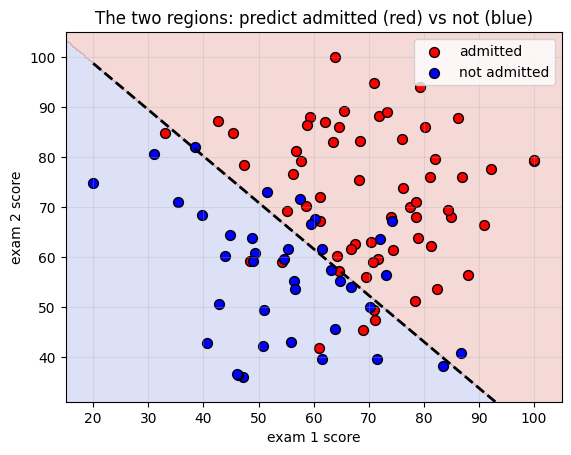

In [23]:
# build a grid covering the plot area
x_min, x_max = df["exam1"].min()-5, df["exam1"].max()+5
y_min, y_max = df["exam2"].min()-5, df["exam2"].max()+5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# ask the model to predict every point in the grid
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

# shade the regions, then plot students on top
plt.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
plot_students(df)
plt.plot(exam1_line, exam2_line, "k--", linewidth=2, label="boundary")
plt.title("The two regions: predict admitted (red) vs not (blue)")
plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
plt.show()

Now the model's logic is completely visible: the **red region** is "predict admitted," the **blue region** is "predict not admitted," and the dashed line is exactly where it switches. Every student's prediction is just *which colour region they land in.*

### Bonus: shading by confidence
Logistic regression gives a *probability*, not just a hard yes/no. If we shade by that probability instead, the colours **fade near the boundary** (where the model is unsure, around 50%) and **deepen far from it** (where it's confident). This shows the model isn't equally sure everywhere.

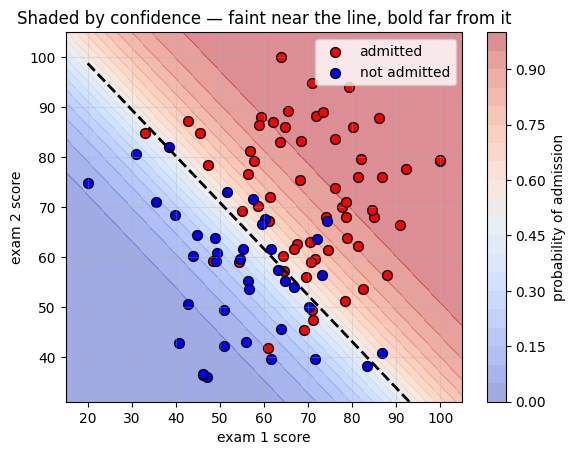

In [8]:
# shade by probability of admission instead of the hard 0/1 decision
Z_prob = model.predict_proba(grid)[:, 1].reshape(xx.shape)

contour = plt.contourf(xx, yy, Z_prob, levels=20, alpha=0.5, cmap="coolwarm")
plt.colorbar(contour, label="probability of admission")
plot_students(df)
plt.plot(exam1_line, exam2_line, "k--", linewidth=2)
plt.title("Shaded by confidence — faint near the line, bold far from it")
plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
plt.show()

See how the colour is **washed-out along the dashed line** — right at the boundary the model is only ~50% sure (it's a coin flip there). Far into the red, it's confidently "admitted"; far into the blue, confidently "not." This is the whole idea of logistic regression in one picture: **a line, with confidence that grows as you move away from it.**

---
## 5. Predicting a new student

The payoff: given a new student's two scores, which side of the line do they fall on?

In [9]:
new_students = pd.DataFrame({
    "exam1": [45, 75, 62],
    "exam2": [50, 85, 60],
})

for i, row in new_students.iterrows():
    scores = [[row["exam1"], row["exam2"]]]
    prob = model.predict_proba(scores)[0][1]
    decision = "ADMITTED" if model.predict(scores)[0] == 1 else "NOT admitted"
    print(f"exam1={row['exam1']}, exam2={row['exam2']}  →  {prob:.0%} likely  →  {decision}")

exam1=45, exam2=50  →  5% likely  →  NOT admitted
exam1=75, exam2=85  →  98% likely  →  ADMITTED
exam1=62, exam2=60  →  51% likely  →  ADMITTED


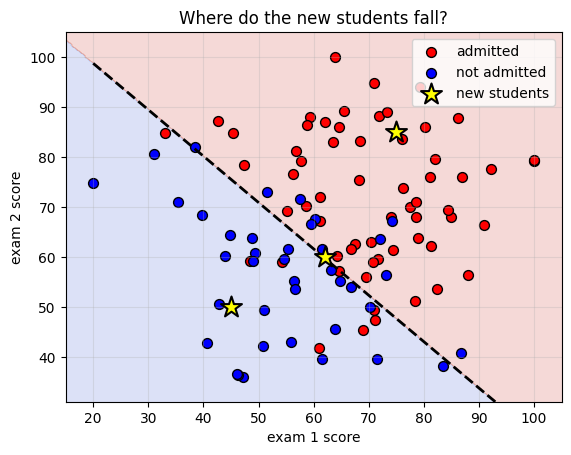

In [10]:
# show where these new students land on the map
plt.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
plot_students(df)
plt.plot(exam1_line, exam2_line, "k--", linewidth=2)
plt.scatter(new_students["exam1"], new_students["exam2"],
            c="yellow", s=250, marker="*", edgecolor="k", linewidth=1.5,
            label="new students", zorder=5)
plt.title("Where do the new students fall?")
plt.legend(); plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
plt.show()

The yellow stars are the new students, dropped onto the map. Each prediction is simply **which region the star lands in** — and how deep into that region tells you how confident the model is. The low-scoring student sits in the blue, the high-scoring one deep in the red, and the middling one near the line (an uncertain call).

---
## Summary

- With **two features**, logistic regression's decision boundary is a **straight line** on the feature plane — the picture everyone describes but rarely sees.
- The line is where `w₁·x₁ + w₂·x₂ + b = 0` (the point where the sigmoid outputs exactly 0.5). Rearranging gives the line's equation directly.
- One side of the line is "predict yes," the other "predict no" — we can **shade** those regions to make the model's logic fully visible.
- Shading by **probability** shows the model is unsure *near* the line and confident *far* from it — logistic regression is "a line, with confidence growing as you move away."
- Predicting a new point is just asking **which side of the line it falls on.**

This is the same model you already knew — we just gave it two features so we could *see* what it does. With three features it becomes a flat plane, and with more, a "hyperplane" we can't draw — but the idea is identical: **a straight divider between the classes.**